<a href="https://colab.research.google.com/github/AmmarKhan010/Hrcandidateevalutation/blob/main/Agentic_AI_Autonomous_Task_Management_POC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Part 1: Install dependencies
!pip install pydantic

In [2]:
# Part 2: Core Framework (for Phase 1 and 2)
import asyncio
import random
from pydantic import BaseModel
from typing import List, Optional
from enum import Enum

# --- PHASE I: PROTOCOLS ---Phase I (Architectural Synthesis): We define the "Standard Language" (Protocols) and the "Team" (Agents). We create a WorkerAgent capable of executing tasks within a software environment.
class TaskPriority(Enum):
    LOW = 1
    MEDIUM = 2
    HIGH = 3

class Task(BaseModel):
    id: int
    description: str
    priority: TaskPriority = TaskPriority.LOW
    status: str = "pending"
    utility_score: float = 0.0

# --- PHASE II: LOGIC (PPO-INSPIRED) --- We implement a calculate_utility function. This simulates the PPO (Proximal Policy Optimization) logic by teaching the agent to prioritize "High Utility" tasks, such as security breaches or emergency alerts, over routine logs.
def calculate_utility(task: Task) -> float:
    score = float(task.priority.value)
    # Priority keywords for MCD Systems workflow
    urgent_keywords = ["emergency", "error", "security", "mcd"]
    if any(word in task.description.lower() for word in urgent_keywords):
        score += 5.0
    return score

def prioritize_tasks(tasks: List[Task]) -> List[Task]:
    for task in tasks:
        task.utility_score = calculate_utility(task)
    return sorted(tasks, key=lambda x: x.utility_score, reverse=True)

# --- PHASE I: AGENTS ---
class WorkerAgent:
    def __init__(self, name: str):
        self.name = name

    async def execute(self, task: Task):
        print(f"[{self.name}] Processing: {task.description} | Score: {task.utility_score}")
        await asyncio.sleep(random.uniform(1, 2))

        # Phase III: Simulated failure rate for MTTR testing
        if random.random() < 0.2:
            raise Exception(f"Connection lost during: {task.description}")

        print(f"[{self.name}] ✅ Task Completed.")
        return True

In [3]:
# Cell 3: Global Controller & Empirical Validation-- This is the Empirical Validation phase. We act as the Global Controller to manage the workflow. We run the agents through a set of tasks and monitor their performance. If a task fails, the controller initiates a "Recovery Protocol" to simulate MTTR (Mean Time to Recovery).
# 1. Setup simulated MCD Systems tasks
raw_tasks = [
    Task(id=1, description="Update routine logs", priority=TaskPriority.LOW),
    Task(id=2, description="Fix MCD Security Breach", priority=TaskPriority.HIGH),
    Task(id=3, description="Respond to emergency maritime alert", priority=TaskPriority.MEDIUM),
    Task(id=4, description="Bespoke software update for client", priority=TaskPriority.LOW),
]

# 2. Optimization
print("--- Phase II: Optimizing Task Queue ---")
optimized_queue = prioritize_tasks(raw_tasks)

# 3. Execution & Validation
worker = WorkerAgent(name="MCD-Agent-Alpha")
successes = 0
total = len(optimized_queue)

print(f"\n--- Phase III: Executing {total} Tasks ---\n")
for task in optimized_queue:
    try:
        await worker.execute(task)
        successes += 1
    except Exception as e:
        print(f"!! ERROR DETECTED: {e}")
        print("Initiating Recovery Protocol (Simulating MTTR)...")
        await asyncio.sleep(1)
        print("System Restored. Moving to next task.")

# 4. Final Metrics
tsr = (successes / total) * 100
print(f"\n--- Final Metrics ---")
print(f"Task Success Rate (TSR): {tsr}%")

--- Phase II: Optimizing Task Queue ---

--- Phase III: Executing 4 Tasks ---

[MCD-Agent-Alpha] Processing: Fix MCD Security Breach | Score: 8.0
[MCD-Agent-Alpha] ✅ Task Completed.
[MCD-Agent-Alpha] Processing: Respond to emergency maritime alert | Score: 7.0
!! ERROR DETECTED: Connection lost during: Respond to emergency maritime alert
Initiating Recovery Protocol (Simulating MTTR)...
System Restored. Moving to next task.
[MCD-Agent-Alpha] Processing: Update routine logs | Score: 1.0
[MCD-Agent-Alpha] ✅ Task Completed.
[MCD-Agent-Alpha] Processing: Bespoke software update for client | Score: 1.0
[MCD-Agent-Alpha] ✅ Task Completed.

--- Final Metrics ---
Task Success Rate (TSR): 75.0%


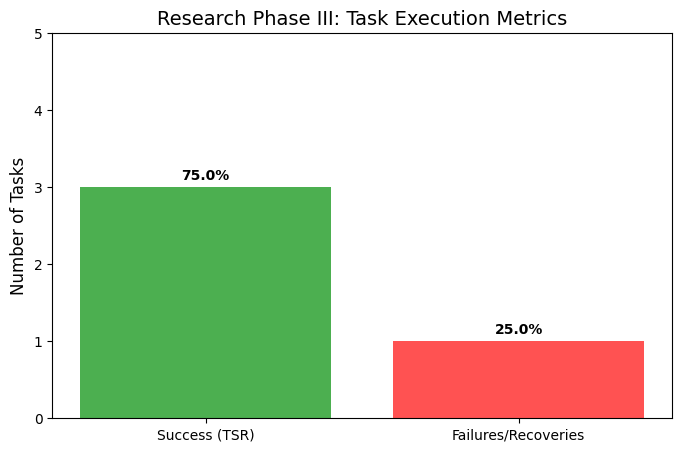

In [4]:
# Cell 4: Phase III Visualization (Empirical Validation)-- We translate the execution data into a visual format. This proves the Task Success Rate (TSR), providing a clear metric for the project's robustness and applicability to diverse client needs.
import matplotlib.pyplot as plt

def plot_results(successes, total):
    failures = total - successes
    labels = ['Success (TSR)', 'Failures/Recoveries']
    counts = [successes, failures]
    colors = ['#4CAF50', '#FF5252']

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color=colors)
    plt.title('Research Phase III: Task Execution Metrics', fontsize=14)
    plt.ylabel('Number of Tasks', fontsize=12)
    plt.ylim(0, total + 1)

    # Add percentage labels on top of bars
    for i, count in enumerate(counts):
        percentage = (count / total) * 100
        plt.text(i, count + 0.1, f'{percentage:.1f}%', ha='center', fontweight='bold')

    plt.show()

# Run visualization using the variables from Cell 3
plot_results(successes, total)